In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [4]:
df.isna().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [6]:
df.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [7]:
df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature',
       'Weather'],
      dtype='object')

In [8]:
for col in df.columns:
    print(df[col].value_counts())

Index
0        1
1        1
2        1
3        1
4        1
        ..
77294    1
77295    1
77296    1
77297    1
77298    1
Name: count, Length: 77299, dtype: int64
geohash
qp03wd    105
qp03wf    105
qp09t0    105
qp03w9    105
qp03x3    105
         ... 
qp08gs      1
qp08fq      1
qp0d1t      1
qp09vc      1
qp09jc      1
Name: count, Length: 1249, dtype: int64
day
48    69427
49     7872
Name: count, dtype: int64
timestamp
2:0      1778
1:45     1755
1:30     1750
1:15     1698
1:0      1668
         ... 
19:30     308
18:30     303
18:45     297
19:0      292
19:15     288
Name: count, Length: 96, dtype: int64
demand
1.000000    585
0.027132      1
0.003272      1
0.010819      1
0.016262      1
           ... 
0.063599      1
0.022749      1
0.093100      1
0.024143      1
0.118507      1
Name: count, Length: 76715, dtype: int64
RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64
NumberofLanes
1    27411
2    24127
3    23919
4    

<Axes: ylabel='Temperature'>

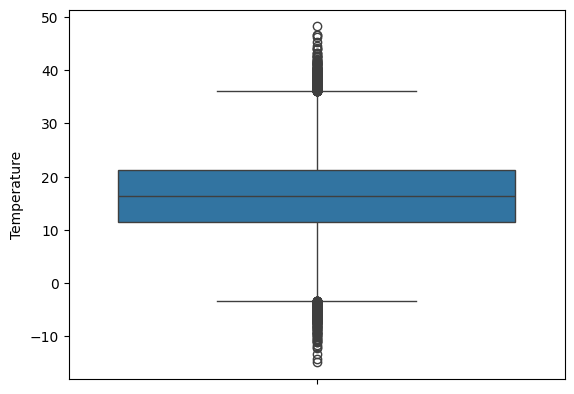

In [9]:
sns.boxplot(df['Temperature'])

<Axes: xlabel='Weather', ylabel='Temperature'>

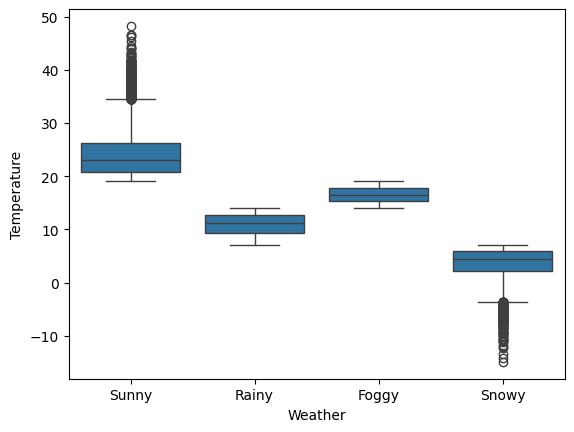

In [10]:
sns.boxplot(x='Weather', y='Temperature', data=df)

In [11]:
df['Weather'].value_counts()

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

In [12]:
df[df['Weather'].isna() & df['Temperature'].isna()]

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
3007,3007,qp091t,48,1:0,0.030008,Residential,3,Allowed,Yes,NaN,NaN
6014,6014,qp03z6,48,1:45,0.002964,Residential,1,Not Allowed,No,NaN,NaN
9021,9021,qp094j,48,2:45,0.002178,Residential,2,Not Allowed,Yes,NaN,NaN
12028,12028,qp09e4,48,3:30,0.085958,Residential,3,Allowed,Yes,NaN,NaN
15035,15035,qp09uk,48,4:15,0.014084,Residential,1,Not Allowed,No,NaN,NaN
18042,18042,qp03p1,48,5:15,0.039419,Residential,3,Allowed,Yes,NaN,NaN
21049,21049,qp03my,48,6:0,0.093137,Residential,3,Allowed,Yes,NaN,NaN
24056,24056,qp099z,48,6:45,0.014960,Residential,3,Allowed,Yes,NaN,NaN
27063,27063,qp08fy,48,7:45,0.021989,Residential,2,Not Allowed,Yes,NaN,NaN


In [13]:
rows_to_drop = df[df['Weather'].isna() & df['Temperature'].isna()].index
df = df.drop(rows_to_drop)

In [14]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


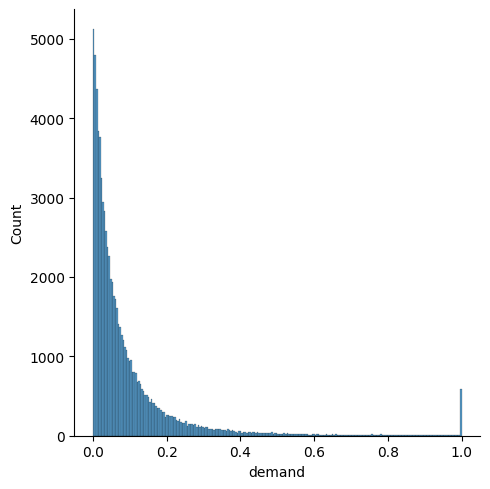

In [15]:
sns.displot(df['demand'])

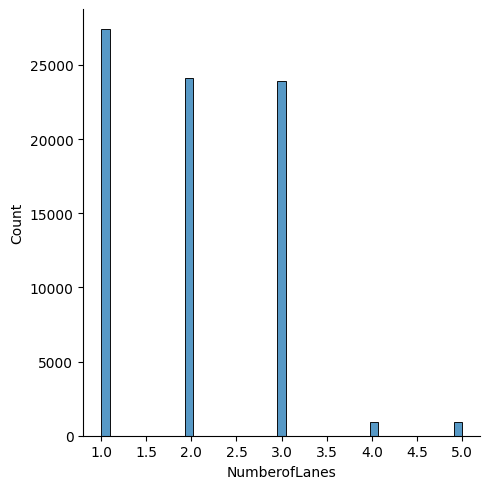

In [16]:
sns.displot(df['NumberofLanes'])

In [17]:
df.drop(columns=['Index'], inplace=True)

In [18]:
df

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [19]:
df['Weather'].value_counts()

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

In [20]:
df.isna().sum()

geohash             0
day                 0
timestamp           0
demand              0
RoadType          599
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2469
Weather           771
dtype: int64

In [21]:
df[df['Weather'].isna()]

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
97,qp03pr,48,0:0,0.075934,Residential,3,Allowed,Yes,20.290262,NaN
194,qp09ke,48,0:0,0.062698,Residential,3,Allowed,Yes,12.675770,NaN
291,qp03x2,48,0:0,0.023717,Residential,3,Allowed,Yes,24.700395,NaN
388,qp03ws,48,0:0,0.036228,Residential,2,Not Allowed,Yes,12.773994,NaN
485,qp03y8,48,0:0,0.056283,Residential,1,Not Allowed,No,15.221394,NaN
...,...,...,...,...,...,...,...,...,...,...
76824,qp03tf,49,2:0,0.058770,Residential,3,Allowed,Yes,16.052896,NaN
76921,qp03xt,49,2:0,0.372385,Highway,4,Allowed,Yes,23.180955,NaN
77018,qp09u2,49,2:0,0.040699,Residential,3,Allowed,Yes,23.360023,NaN
77115,qp09vk,49,2:0,0.150193,Residential,3,Allowed,Yes,16.396076,NaN


<Axes: xlabel='Weather', ylabel='Temperature'>

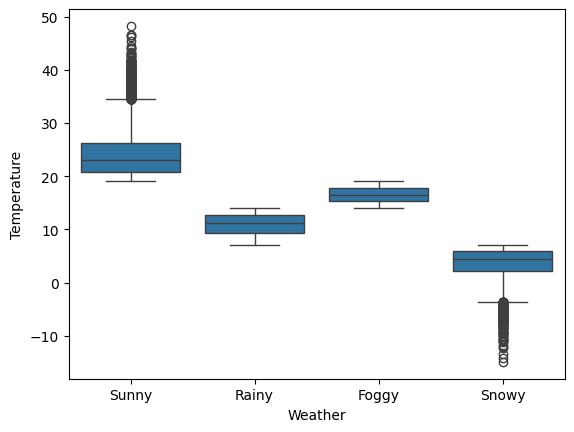

In [22]:
sns.boxplot(x='Weather', y='Temperature', data=df)

In [24]:
df.columnsdf

Index(['geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather'],
      dtype='object')

In [25]:
df['Weather'].unique()

array(['Sunny', 'Rainy', 'Foggy', 'Snowy', nan], dtype=object)

In [28]:
df[df['Weather'] == 'Sunny']

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
11,qp02zr,48,0:0,0.089060,Residential,2,Not Allowed,Yes,19.245381,Sunny
16,qp08bz,48,0:0,0.001492,Residential,1,Not Allowed,No,19.266717,Sunny
17,qp08cp,48,0:0,0.003284,Residential,3,Allowed,Yes,24.318534,Sunny
...,...,...,...,...,...,...,...,...,...,...
77288,qp06py,49,2:0,0.063179,Residential,2,Not Allowed,Yes,28.022363,Sunny
77289,qp0d0n,49,2:0,0.027741,Residential,3,Allowed,Yes,26.176992,Sunny
77292,qp0d1q,49,2:0,0.007453,Residential,3,Allowed,Yes,19.906633,Sunny
77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny


In [ ]:
mean_temperature_by_weather = []
for w in df['Weather'].unique():
    mean_temperature_by_weather.append(df['Weather'])

In [29]:
weather_median = df.groupby('Weather')['Temperature'].median()
weather_median


Weather
Foggy    16.475623
Rainy    11.141699
Snowy     4.403676
Sunny    23.049061
Name: Temperature, dtype: float64

In [30]:
mask = df['Temperature'].isna() & df['Weather'].notna()

df.loc[mask, 'Temperature'] = (
    df.loc[mask, 'Weather'].map(weather_median)
)

In [31]:
df.groupby('Weather')['Temperature'].median().sort_values()

Weather
Snowy     4.403676
Rainy    11.141699
Foggy    16.475623
Sunny    23.049061
Name: Temperature, dtype: float64

In [104]:
# snowy_rainy = (4.403676 + 11.141699) / 2   # 7.77
# rainy_foggy = (11.141699 + 16.475623) / 2  # 13.81
# foggy_sunny = (16.475623 + 23.049061) / 2  # 19.76
def infer_weather(temp):
    if temp < 7.77:
        return 'Snowy'
    elif temp < 13.81:
        return 'Rainy'
    elif temp < 19.76:
        return 'Foggy'
    else:
        return 'Sunny'

In [33]:
known = df[df['Weather'].notna()].copy()

known['pred_weather'] = known['Temperature'].apply(infer_weather)

accuracy = (
    known['pred_weather'] == known['Weather']
).mean()

print(f"Accuracy = {accuracy:.4f}")

Accuracy = 0.9336


In [34]:
mask = df['Weather'].isna()

df.loc[mask, 'Weather'] = (
    df.loc[mask, 'Temperature'].apply(infer_weather)
)

In [36]:
df.isna().sum()

geohash            0
day                0
timestamp          0
demand             0
RoadType         599
NumberofLanes      0
LargeVehicles      0
Landmarks          0
Temperature        0
Weather            0
dtype: int64

In [37]:
# No missing values left
df[['Temperature', 'Weather']].isna().sum()

Temperature    0
Weather        0
dtype: int64

In [38]:
# Check weather distribution
df['Weather'].value_counts(normalize=True)

Weather
Sunny    0.362002
Rainy    0.272074
Foggy    0.265021
Snowy    0.100902
Name: proportion, dtype: float64

In [40]:
df['RoadType'].value_counts()

RoadType
Residential    69206
Street          3909
Highway         3559
Name: count, dtype: int64

In [41]:
df['RoadType'].unique()

array(['Residential', 'Street', nan, 'Highway'], dtype=object)

In [42]:
df

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,11.141699,Rainy
4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [45]:
df['NumberofLanes'].value_counts()

NumberofLanes
1    27401
2    24119
3    23911
4      926
5      916
Name: count, dtype: int64

<Axes: xlabel='RoadType', ylabel='NumberofLanes'>

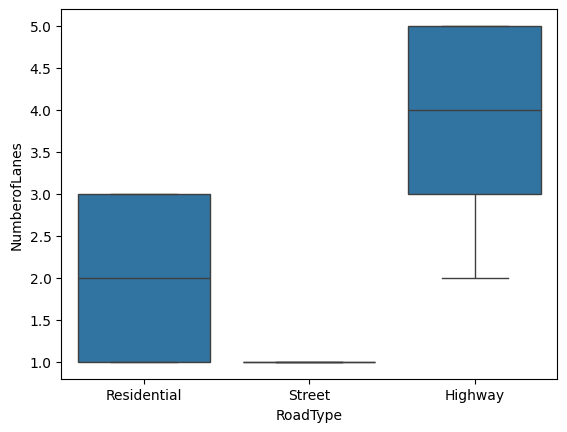

In [44]:
sns.boxplot(y='NumberofLanes', x='RoadType', data=df)

In [46]:
pd.crosstab(
    df['NumberofLanes'],
    df['RoadType'],
    margins=True
)

RoadType,Highway,Residential,Street,All
NumberofLanes,,,,
1,0,23260,3909,27169
2,854,23084,0,23938
3,881,22862,0,23743
4,915,0,0,915
5,909,0,0,909
All,3559,69206,3909,76674


In [47]:
df.groupby('geohash')['RoadType'].nunique().value_counts()

RoadType
1    994
2    128
3    127
Name: count, dtype: int64

In [48]:
missing = df[df['RoadType'].isna()]

missing['NumberofLanes'].value_counts()

NumberofLanes
1    232
2    181
3    168
4     11
5      7
Name: count, dtype: int64

In [49]:
pd.crosstab(df['LargeVehicles'], df['RoadType'])

RoadType,Highway,Residential,Street
LargeVehicles,,,
Allowed,3559,22862,0
Not Allowed,0,46344,3909


In [50]:
pd.crosstab(df['Landmarks'], df['RoadType'])

RoadType,Highway,Residential,Street
Landmarks,,,
No,1763,23260,0
Yes,1796,45946,3909


In [51]:
def infer_roadtype(lanes, large_vehicles):
    
    if large_vehicles == 'Allowed':
        if lanes >= 4:
            return 'Highway'
        elif lanes in [2, 3]:
            return 'Residential'  # could be Highway, but Residential is much more common
        else:
            return 'Residential'

    else:  # Not Allowed
        if lanes == 1:
            return 'Street'
        else:
            return 'Residential'

In [52]:
known = df[df['RoadType'].notna()].copy()

known['pred'] = known.apply(
    lambda row: infer_roadtype(
        row['NumberofLanes'],
        row['LargeVehicles']
    ),
    axis=1
)

(known['pred'] == known['RoadType']).mean()

np.float64(0.674009442575058)

In [53]:
pd.crosstab(
    [df['NumberofLanes'], df['LargeVehicles']],
    df['RoadType']
)

RoadType                     Highway  Residential  Street
NumberofLanes LargeVehicles                              
1             Not Allowed          0        23260    3909
2             Allowed            854            0       0
              Not Allowed          0        23084       0
3             Allowed            881        22862       0
4             Allowed            915            0       0
5             Allowed            909            0       0

In [54]:
mapping = (
    df[df['RoadType'].notna()]
    .groupby(['NumberofLanes', 'LargeVehicles'])['RoadType']
    .agg(lambda x: x.mode().iloc[0])
)

print(mapping)

NumberofLanes  LargeVehicles
1              Not Allowed      Residential
2              Allowed              Highway
               Not Allowed      Residential
3              Allowed          Residential
4              Allowed              Highway
5              Allowed              Highway
Name: RoadType, dtype: object


In [55]:
df[df['RoadType'].isna()][['NumberofLanes', 'LargeVehicles']].drop_duplicates()

,NumberofLanes,LargeVehicles
129,2,Not Allowed
258,1,Not Allowed
387,3,Allowed
4902,5,Allowed
10191,4,Allowed
15093,2,Allowed


In [56]:
mapping = (
    df[df['RoadType'].notna()]
    .groupby(['NumberofLanes', 'LargeVehicles'])['RoadType']
    .agg(lambda x: x.mode().iloc[0])
)

mask = df['RoadType'].isna()

df.loc[mask, 'RoadType'] = df.loc[mask].apply(
    lambda row: mapping.loc[
        (row['NumberofLanes'], row['LargeVehicles'])
    ],
    axis=1
)

In [57]:
df.isna().sum()

geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

In [58]:
df['demand'].describe()

count    7.727300e+04
mean     9.395319e-02
std      1.422009e-01
min      6.245650e-07
25%      1.822724e-02
50%      4.777371e-02
75%      1.086053e-01
max      1.000000e+00
Name: demand, dtype: float64

In [59]:
(df['demand'] == 1).sum()

np.int64(585)

In [60]:
(df['demand'] == 1).mean()

np.float64(0.007570561515665239)

## Feature Engineering

In [61]:
df['hour'] = df['timestamp'].str.split(':').str[0].astype(int)
df['minute'] = df['timestamp'].str.split(':').str[1].astype(int)

In [62]:
df

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute
1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0
2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0
3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,11.141699,Rainy,0,0
4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0
5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy,2,0
77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy,2,0
77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny,2,0
77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny,2,0


In [63]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [64]:
df

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos
1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0.0,1.000000
2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0.0,1.000000
3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,11.141699,Rainy,0,0,0.0,1.000000
4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0.0,1.000000
5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy,0,0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy,2,0,0.5,0.866025
77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy,2,0,0.5,0.866025
77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny,2,0,0.5,0.866025
77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny,2,0,0.5,0.866025


In [65]:
df['LargeVehicles'].unique()

array(['Allowed', 'Not Allowed'], dtype=object)

In [66]:
df['Landmarks'].unique()

array(['Yes', 'No'], dtype=object)

In [67]:
df['LargeVehicles'] = df['LargeVehicles'].map({
    'Allowed': 1,
    'Not Allowed': 0
})

df['Landmarks'] = df['Landmarks'].map({
    'Yes': 1,
    'No': 0
})

In [68]:
df

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos
1,qp02zt,48,0:0,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000
2,qp08bj,48,0:0,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000
3,qp08gt,48,0:0,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000
4,qp02zq,48,0:0,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000
5,qp02zw,48,0:0,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,2:0,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025
77295,qp0d4q,49,2:0,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025
77296,qp0d4w,49,2:0,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025
77297,qp0dhw,49,2:0,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025


In [69]:
df['minute'].value_counts()

minute
0     19970
45    19154
30    19111
15    19038
Name: count, dtype: int64

In [70]:
df['hour'].value_counts()

hour
1     6868
0     6336
2     4454
4     3682
6     3663
10    3621
5     3620
3     3594
7     3568
11    3565
9     3548
12    3524
8     3506
13    3270
23    3061
14    2999
15    2579
22    2409
16    2108
21    1737
17    1683
20    1418
18    1247
19    1213
Name: count, dtype: int64

In [71]:
df.drop(columns=['timestamp'], inplace=True)

In [72]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos
1,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000
2,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000
3,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000
4,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000
5,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025
77295,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025
77296,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025
77297,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025


In [73]:
df['day'].nunique()

2

In [75]:
df['day'].value_counts()

day
48    69403
49     7870
Name: count, dtype: int64

In [76]:
df['time_slot'] = df['hour'] * 4 + (df['minute'] // 15)

In [77]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot
1,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0
2,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0
3,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0
4,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0
5,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8
77295,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8
77296,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8
77297,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8


In [78]:
for col in ['geohash','RoadType','Weather','day']:
    print(col, df[col].nunique())

geohash 1249
RoadType 3
Weather 4
day 2


In [79]:
df.groupby('hour')['demand'].mean()

hour
0     0.083373
1     0.089749
2     0.087387
3     0.091331
4     0.101702
5     0.104386
6     0.103940
7     0.106221
8     0.106169
9     0.109252
10    0.111609
11    0.117297
12    0.114784
13    0.116343
14    0.107194
15    0.083179
16    0.070065
17    0.058938
18    0.048787
19    0.042146
20    0.043778
21    0.056967
22    0.074567
23    0.092537
Name: demand, dtype: float64

In [80]:
df.groupby('Weather')['demand'].mean().sort_values()

Weather
Snowy    0.092441
Foggy    0.093602
Sunny    0.094158
Rainy    0.094583
Name: demand, dtype: float64

In [81]:
df.groupby('RoadType')['demand'].mean().sort_values()

RoadType
Residential    0.057357
Street         0.273164
Highway        0.610555
Name: demand, dtype: float64

In [82]:
df.groupby('hour')['demand'].mean()

hour
0     0.083373
1     0.089749
2     0.087387
3     0.091331
4     0.101702
5     0.104386
6     0.103940
7     0.106221
8     0.106169
9     0.109252
10    0.111609
11    0.117297
12    0.114784
13    0.116343
14    0.107194
15    0.083179
16    0.070065
17    0.058938
18    0.048787
19    0.042146
20    0.043778
21    0.056967
22    0.074567
23    0.092537
Name: demand, dtype: float64

In [83]:
df.groupby('NumberofLanes')['demand'].mean()

NumberofLanes
1    0.088122
2    0.077480
3    0.077867
4    0.602882
5    0.607556
Name: demand, dtype: float64

In [84]:
df.groupby('geohash')['demand'].mean().describe()

count    1249.000000
mean        0.064670
std         0.099858
min         0.000495
25%         0.012661
50%         0.030807
75%         0.075227
max         0.960715
Name: demand, dtype: float64

In [85]:
df['geohash'].nunique()

1249

In [86]:
!pip install pygeohash


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
import pygeohash as pgh

lat, lon = pgh.decode('qp02zt')
print(lat, lon)

-5.46295166015625 90.6866455078125


In [88]:
import pygeohash as pgh

df[['latitude', 'longitude']] = df['geohash'].apply(
    lambda x: pd.Series(pgh.decode(x))
)

In [89]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
1,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646
2,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618
3,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427
4,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659
5,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509
77295,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495
77296,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481
77297,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372


In [90]:
df[['latitude','longitude','demand']].corr()

,latitude,longitude,demand
latitude,1.000000,0.115868,-0.039266
longitude,0.115868,1.000000,-0.006767
demand,-0.039266,-0.006767,1.000000


In [91]:
df.columns

Index(['geohash', 'day', 'demand', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour',
       'minute', 'hour_sin', 'hour_cos', 'time_slot', 'latitude', 'longitude'],
      dtype='object')

# Model Training

In [92]:
!pip install catboost

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.4/100.2 MB 7.7 MB/s eta 0:00:13
   - -------------------------------------- 4.5/100.2 MB 7.8 MB/s eta 0:00:13
   - -------------------------------------- 4.7/100.2 MB 6.3 MB/s eta 0:00:16
   -- ------------------------------------- 5.5/100.2 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 6.0/100.2 MB 4.8 MB/s eta 0:00:20
   -- ------------------------------------- 7.3/100.2 MB 5.1 MB/s eta 0:00:19
   --- ------------------------------------ 7.6/100.2 MB 4.6 MB/s eta 0:00:21
   --- ------------------------------------ 8.4/100.2 MB 4.5 MB/s eta 0:00:21
   --- ------------------------------------ 9.4/100.2 MB 4.5 MB/s eta 0:00:21
   ---- -------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
import numpy as np

X = df.drop(columns=['demand'])
y = df['demand']

cat_features = [
    'geohash',
    'day',
    'RoadType',
    'Weather'
]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        early_stopping_rounds=200,
        verbose=True
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)
    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

print("\nMean R²:", np.mean(scores))
print("Std R²:", np.std(scores))

0:	learn: 0.1391783	test: 0.1380077	best: 0.1380077 (0)	total: 222ms	remaining: 11m 6s
1:	learn: 0.1359963	test: 0.1348673	best: 0.1348673 (1)	total: 345ms	remaining: 8m 36s
2:	learn: 0.1329751	test: 0.1318779	best: 0.1318779 (2)	total: 460ms	remaining: 7m 39s
3:	learn: 0.1301105	test: 0.1290492	best: 0.1290492 (3)	total: 529ms	remaining: 6m 35s
4:	learn: 0.1273362	test: 0.1262717	best: 0.1262717 (4)	total: 639ms	remaining: 6m 22s
5:	learn: 0.1246447	test: 0.1236038	best: 0.1236038 (5)	total: 727ms	remaining: 6m 2s
6:	learn: 0.1220963	test: 0.1210991	best: 0.1210991 (6)	total: 829ms	remaining: 5m 54s
7:	learn: 0.1196226	test: 0.1186586	best: 0.1186586 (7)	total: 944ms	remaining: 5m 53s
8:	learn: 0.1172376	test: 0.1163029	best: 0.1163029 (8)	total: 999ms	remaining: 5m 32s
9:	learn: 0.1149261	test: 0.1140200	best: 0.1140200 (9)	total: 1.13s	remaining: 5m 36s
10:	learn: 0.1127577	test: 0.1118931	best: 0.1118931 (10)	total: 1.17s	remaining: 5m 17s
11:	learn: 0.1106131	test: 0.1097714	best:

In [94]:
importance = model.get_feature_importance(prettified=True)
print(importance)

       Feature Id  Importances
0        RoadType    44.733237
1         geohash    15.820997
2   NumberofLanes    10.531019
3   LargeVehicles     6.287039
4       longitude     5.421571
5        latitude     4.466180
6       time_slot     3.410667
7        hour_cos     3.276002
8        hour_sin     2.971806
9             day     1.055420
10           hour     0.989709
11    Temperature     0.427270
12        Weather     0.316588
13         minute     0.198365
14      Landmarks     0.094129


In [95]:
from catboost import CatBoostRegressor

X = df.drop(columns=['demand'])
y = df['demand']

cat_features = [
    'geohash',
    'day',
    'RoadType',
    'Weather'
]

final_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

final_model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	learn: 0.1390096	total: 59.4ms	remaining: 2m 58s
100:	learn: 0.0438744	total: 7.63s	remaining: 3m 39s
200:	learn: 0.0389900	total: 15.6s	remaining: 3m 37s
300:	learn: 0.0370428	total: 24s	remaining: 3m 35s
400:	learn: 0.0355649	total: 32.5s	remaining: 3m 30s
500:	learn: 0.0343967	total: 40.6s	remaining: 3m 22s
600:	learn: 0.0333622	total: 49.1s	remaining: 3m 16s
700:	learn: 0.0325232	total: 57.6s	remaining: 3m 9s
800:	learn: 0.0318075	total: 1m 6s	remaining: 3m 1s
900:	learn: 0.0311584	total: 1m 14s	remaining: 2m 53s
1000:	learn: 0.0305852	total: 1m 23s	remaining: 2m 46s
1100:	learn: 0.0300411	total: 1m 31s	remaining: 2m 38s
1200:	learn: 0.0295999	total: 1m 40s	remaining: 2m 30s
1300:	learn: 0.0291504	total: 1m 49s	remaining: 2m 22s
1400:	learn: 0.0287572	total: 1m 57s	remaining: 2m 14s
1500:	learn: 0.0284614	total: 2m 6s	remaining: 2m 6s
1600:	learn: 0.0281938	total: 2m 15s	remaining: 1m 58s
1700:	learn: 0.0279181	total: 2m 24s	remaining: 1m 50s
1800:	learn: 0.0276764	total: 2m 32s

CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [130]:
test_df = pd.read_csv('test.csv')

In [131]:
test_df

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy
...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy


In [132]:
test_df.isna().sum()

Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [133]:
test_df.drop(columns=['Index'],inplace=True)

In [134]:
test_df

,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy
...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny
41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy
41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy
41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy


In [135]:
weather_temp_map = {
    'Snowy': 4.403676,
    'Rainy': 11.141699,
    'Foggy': 16.475623,
    'Sunny': 23.049061
}

mask = (
    test_df['Temperature'].isna() &
    test_df['Weather'].notna()
)

test_df.loc[mask, 'Temperature'] = (
    test_df.loc[mask, 'Weather']
           .map(weather_temp_map)
)

In [136]:
mask = (
    test_df['Weather'].isna() &
    test_df['Temperature'].notna()
)

test_df.loc[mask, 'Weather'] = (
    test_df.loc[mask, 'Temperature']
           .apply(infer_weather)
)

In [137]:
roadtype_map = {
    (1, 0): 'Residential',
    (2, 0): 'Residential',
    (2, 1): 'Highway',
    (3, 1): 'Residential',
    (4, 1): 'Highway',
    (5, 1): 'Highway'
}

In [138]:
test_df['LargeVehicles'] = (
    test_df['LargeVehicles']
        .map({
            'Allowed': 1,
            'Not Allowed': 0
        })
)

In [139]:
mask = test_df['RoadType'].isna()

test_df.loc[mask, 'RoadType'] = (
    test_df.loc[mask]
    .apply(
        lambda row: roadtype_map[
            (row['NumberofLanes'],
             row['LargeVehicles'])
        ],
        axis=1
    )
)

In [140]:
test_df['Landmarks'] = (
    test_df['Landmarks']
        .map({
            'Yes': 1,
            'No': 0
        })
)

In [141]:
test_df['hour'] = (
    test_df['timestamp']
           .str.split(':')
           .str[0]
           .astype(int)
)

test_df['minute'] = (
    test_df['timestamp']
           .str.split(':')
           .str[1]
           .astype(int)
)

In [142]:
import numpy as np

test_df['hour_sin'] = np.sin(
    2 * np.pi * test_df['hour'] / 24
)

test_df['hour_cos'] = np.cos(
    2 * np.pi * test_df['hour'] / 24
)

In [143]:
test_df['time_slot'] = (
    test_df['hour'] * 4 +
    test_df['minute'] // 15
)

In [144]:
import pygeohash as pgh
import pandas as pd

test_df[['latitude', 'longitude']] = (
    test_df['geohash']
    .apply(lambda x: pd.Series(pgh.decode(x)))
)

In [145]:
test_df.drop(columns=['timestamp'], inplace=True)

In [146]:
print(test_df.columns)

Index(['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles',
       'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'hour_sin',
       'hour_cos', 'time_slot', 'latitude', 'longitude'],
      dtype='object')


In [147]:
test_df

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,NaN,NaN,2,15,0.500000,0.866025,9,-5.484924,90.664673
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372


In [148]:
test_df.isna().sum()

geohash           0
day               0
RoadType          0
NumberofLanes     0
LargeVehicles     0
Landmarks         0
Temperature      14
Weather          14
hour              0
minute            0
hour_sin          0
hour_cos          0
time_slot         0
latitude          0
longitude         0
dtype: int64

In [149]:
test_df[test_df['Temperature'].isna()]

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,NaN,NaN,2,15,5.000000e-01,8.660254e-01,9,-5.484924,90.664673
3007,qp03mm,49,Residential,3,1,1,NaN,NaN,3,0,7.071068e-01,7.071068e-01,12,-5.375061,90.587769
6014,qp09tr,49,Residential,3,1,1,NaN,NaN,3,45,7.071068e-01,7.071068e-01,15,-5.320129,90.939331
9021,qp0d49,49,Residential,2,0,1,NaN,NaN,4,30,8.660254e-01,5.000000e-01,18,-5.265198,90.818481
12028,qp095v,49,Residential,3,1,1,NaN,NaN,5,30,9.659258e-01,2.588190e-01,22,-5.419006,90.873413
15035,qp0990,49,Residential,3,1,1,NaN,NaN,6,15,1.000000e+00,6.123234e-17,25,-5.358582,90.752563
18042,qp09yh,49,Residential,2,0,1,NaN,NaN,7,0,9.659258e-01,-2.588190e-01,28,-5.292664,90.972290
21049,qp091y,49,Residential,1,0,0,NaN,NaN,8,0,8.660254e-01,-5.000000e-01,32,-5.413513,90.785522
24056,qp099e,49,Residential,1,0,0,NaN,NaN,8,45,8.660254e-01,-5.000000e-01,35,-5.342102,90.774536
27063,qp03yx,49,Residential,1,0,0,NaN,NaN,9,30,7.071068e-01,-7.071068e-01,38,-5.276184,90.642700


In [150]:
mask = (
    test_df['Temperature'].isna() &
    test_df['Weather'].isna()
)
global_weather = df['Weather'].mode()[0]
global_temp = df['Temperature'].mean()

test_df.loc[mask, 'Weather'] = global_weather
test_df.loc[mask, 'Temperature'] = global_temp

In [151]:
test_df.isna().sum()

geohash          0
day              0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
hour             0
minute           0
hour_sin         0
hour_cos         0
time_slot        0
latitude         0
longitude        0
dtype: int64

In [152]:
test_pred = final_model.predict(test_df)

In [155]:
test_original = pd.read_csv("test.csv")
print(test_original.columns)

Index(['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather'],
      dtype='object')


In [156]:
submission = pd.DataFrame({
    'Index': test_original['Index'],
    'demand': test_pred
})

In [157]:
print(submission.shape)
print(submission.head())

(41778, 2)
   Index    demand
0      0  0.051890
1      1  0.034327
2      2  0.012988
3      3  0.034128
4      4  0.069989


In [158]:
submission.to_csv("submission1.csv", index=False)

In [159]:
import joblib

joblib.dump(final_model, "catboost_traffic_model.pkl")

['catboost_traffic_model.pkl']

In [160]:
final_model.save_model("catboost_traffic_model.cbm")

In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor()
model.load_model("catboost_traffic_model.cbm")